In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
import threading
import torch.multiprocessing as mp
import copy

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [23]:
class SharedActorCritic(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_actions):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()

        )

        self.actorHead = nn.Sequential(
            nn.Linear(hidden_dim,num_actions),
            nn.Softmax(dim=-1)
        )

        self.criticHead = nn.Sequential(
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self,x):
        shared_output = self.shared(x)
        actorHead_output = self.actorHead(shared_output)
        criticHead_output = self.criticHead(shared_output)

        return actorHead_output, criticHead_output


In [24]:
model = SharedActorCritic(8,256,4)
model.share_memory()

optimizer = optim.Adam(model.parameters(), lr = 3e-4)

In [25]:
all_rewards = {0: [], 1: []}
def workers(thread_id, global_model, optimizer, num_episodes, lock, all_rewards):
    env = gym.make('LunarLander-v3')

    for episode in range(num_episodes):
        obs,_ = env.reset()

        local_model = copy.deepcopy(global_model)

        log_probs = []
        values = []
        rewards = []


        done = False
        while not done:
            obs_tensor = torch.FloatTensor(obs).unsqueeze(0)
            action_probs, value = local_model(obs_tensor)
            dist = torch.distributions.Categorical(action_probs)
            action = dist.sample()
            prob = dist.log_prob(action)
            log_probs.append(prob)

            values.append(value.squeeze())

            action = action.item()
            obs, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            if terminated or truncated:
                done = True
        
        returns = []
        R = 0
        gamma = 0.99

        for reward in reversed(rewards):
            R = reward + gamma * R
            returns.insert(0, R)

        returns_tensor = torch.tensor(returns, dtype=torch.float32)
        log_probs_tensor = torch.stack(log_probs)
        values_tensor = torch.stack(values)

        advantage = (returns_tensor - values_tensor).detach()
        entropy = dist.entropy().mean()
        actor_loss = -(log_probs_tensor * advantage).mean() - 0.01 * entropy
        critic_loss = F.mse_loss(values_tensor,returns_tensor)

        with lock:
            optimizer.zero_grad()

            total_loss = actor_loss + critic_loss
            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(global_model.parameters(), max_norm=0.5)

            optimizer.step()
            all_rewards[thread_id].append(sum(rewards))
            print(f"Thread {thread_id} | Episode {episode} | Reward: {sum(rewards)}")

                        

In [26]:
lock = threading.Lock()
threads = []
for i in range(2):
    t = threading.Thread(target=workers, args=(i, model, optimizer, 1500, lock, all_rewards))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

Thread 1 | Episode 0 | Reward: -194.49903223007013
Thread 0 | Episode 0 | Reward: -368.84477886356575
Thread 1 | Episode 1 | Reward: -261.23205233920544
Thread 0 | Episode 1 | Reward: -95.83811851447541
Thread 1 | Episode 2 | Reward: -348.94562853619277
Thread 0 | Episode 2 | Reward: -282.26430191049394
Thread 1 | Episode 3 | Reward: -170.70789899514907
Thread 0 | Episode 3 | Reward: -361.3683606731283
Thread 1 | Episode 4 | Reward: -265.07629176809814
Thread 0 | Episode 4 | Reward: -111.08172382649373
Thread 1 | Episode 5 | Reward: -287.5632221777199
Thread 0 | Episode 5 | Reward: -92.04554155302735
Thread 1 | Episode 6 | Reward: -57.031171252896804
Thread 0 | Episode 6 | Reward: -100.03213983657106
Thread 1 | Episode 7 | Reward: 20.40703450211926
Thread 0 | Episode 7 | Reward: -107.44997928934374
Thread 1 | Episode 8 | Reward: -305.80593191808964
Thread 0 | Episode 8 | Reward: 16.93342997179961
Thread 1 | Episode 9 | Reward: -105.47327224696373
Thread 0 | Episode 9 | Reward: -101.627

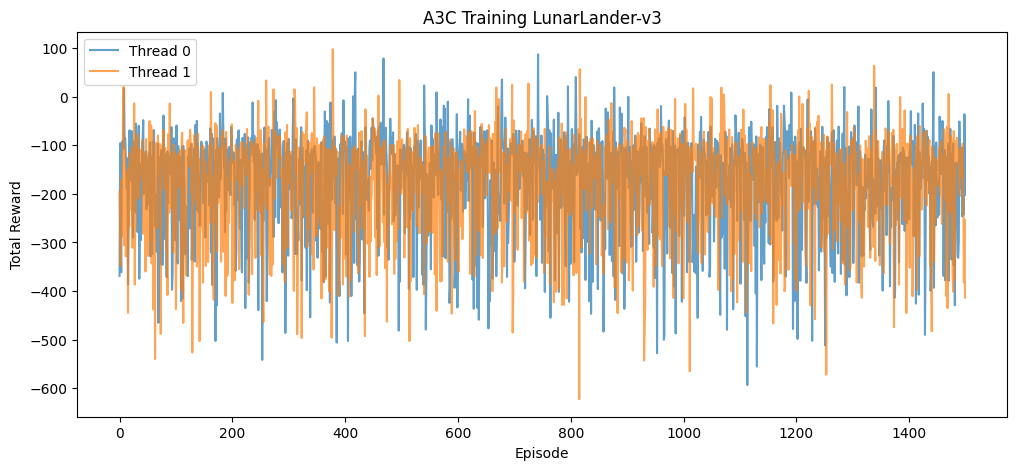

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(all_rewards[0], label='Thread 0', alpha=0.7)
plt.plot(all_rewards[1], label='Thread 1', alpha=0.7)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('A3C Training LunarLander-v3')
plt.legend()
plt.show()

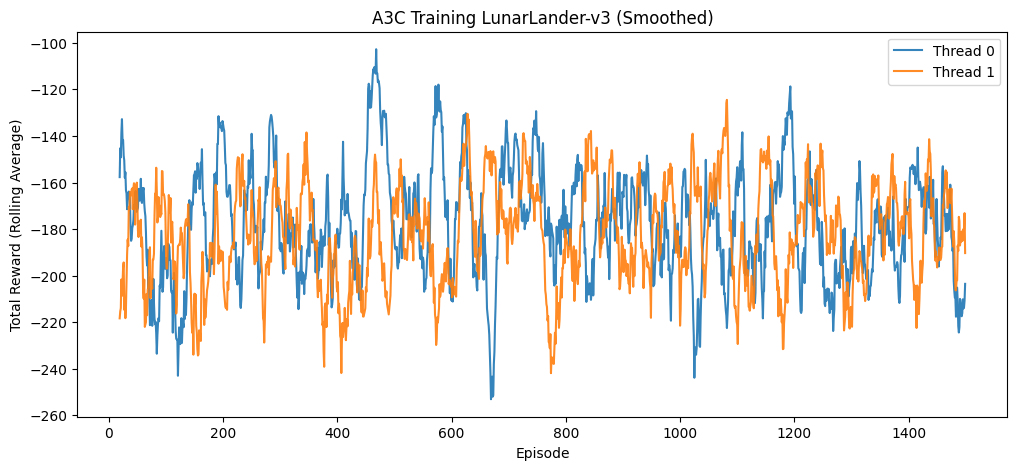

In [28]:
import pandas as pd

window = 20 

plt.figure(figsize=(12, 5))
plt.plot(pd.Series(all_rewards[0]).rolling(window).mean(), label='Thread 0', alpha=0.9)
plt.plot(pd.Series(all_rewards[1]).rolling(window).mean(), label='Thread 1', alpha=0.9)
plt.xlabel('Episode')
plt.ylabel('Total Reward (Rolling Average)')
plt.title('A3C Training LunarLander-v3 (Smoothed)')
plt.legend()
plt.show()

In [29]:
model.eval()
eval_rewards = []
env = gym.make('LunarLander-v3')

for episode in range(10):
    obs, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0)

        action_probs, value = model(obs_tensor)
        action = torch.argmax(action_probs)
        action = action.item()
        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        if terminated or truncated:
            done = True
    
    eval_rewards.append(total_reward)
    print(f"Eval Episode {episode} | Reward: {total_reward}")

Eval Episode 0 | Reward: -530.7738745947036
Eval Episode 1 | Reward: -764.2021095851937
Eval Episode 2 | Reward: -496.67500130130077
Eval Episode 3 | Reward: -729.1549549645841
Eval Episode 4 | Reward: -622.2148413612898
Eval Episode 5 | Reward: -328.71948536800596
Eval Episode 6 | Reward: -514.9551802972594
Eval Episode 7 | Reward: -517.6213001384328
Eval Episode 8 | Reward: -424.2219991234047
Eval Episode 9 | Reward: -501.99864959981016


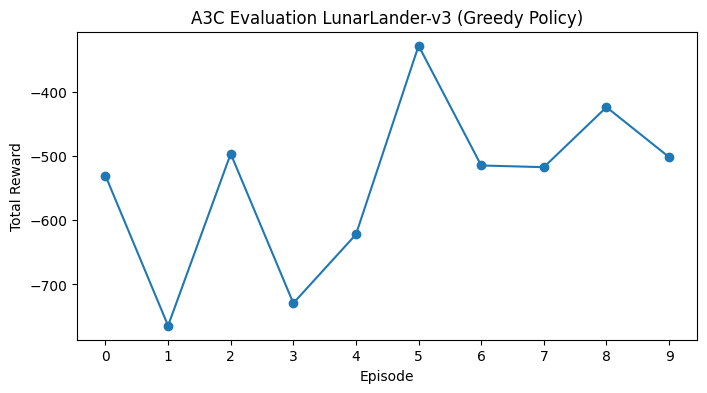

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(eval_rewards, marker='o')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('A3C Evaluation LunarLander-v3 (Greedy Policy)')
plt.xticks(range(10))
plt.show()

In [5]:
%pip install "gymnasium[other]"


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
from save_rendered_video import run_and_record_one_episode

def greedy_policy(obs):
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0)
    with torch.no_grad():
        action_probs, _ = model(obs_tensor)
    return torch.argmax(action_probs).item()

run_and_record_one_episode('LunarLander-v3', greedy_policy, out_dir='videos')

/opt/homebrew/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/aryaapareshdeshpande/Desktop/Reinforcement Learning/Assignment 3 - Checkpoint attached files Apr 9, 2026 547 PM/Actor-Critic-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Saved video in videos. Episode reward: -146.1870018198181, steps: 63


In [31]:
torch.save(model.state_dict(), 'a3_part_3_a3c_lunarlander_aryaapar.pth')

In [32]:
model = SharedActorCritic(8, 256, 4)
model.load_state_dict(torch.load('a3_part_3_a3c_lunarlander_aryaapar.pth'))
model.eval()
eval_rewards = []
env = gym.make('LunarLander-v3')

for episode in range(10):
    obs, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0)

        action_probs, value = model(obs_tensor)
        action = torch.argmax(action_probs)
        action = action.item()
        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        if terminated or truncated:
            done = True
    
    eval_rewards.append(total_reward)
    print(f"Eval Episode {episode} | Reward: {total_reward}")

Eval Episode 0 | Reward: -141.6093578606412
Eval Episode 1 | Reward: -252.8726133181644
Eval Episode 2 | Reward: -111.79774738745758
Eval Episode 3 | Reward: -124.85231714715587
Eval Episode 4 | Reward: -144.6513741793142
Eval Episode 5 | Reward: -438.72102568415784
Eval Episode 6 | Reward: -131.38082888918973
Eval Episode 7 | Reward: 49.20656220759986
Eval Episode 8 | Reward: -93.59583919734081
Eval Episode 9 | Reward: -116.0018877298471


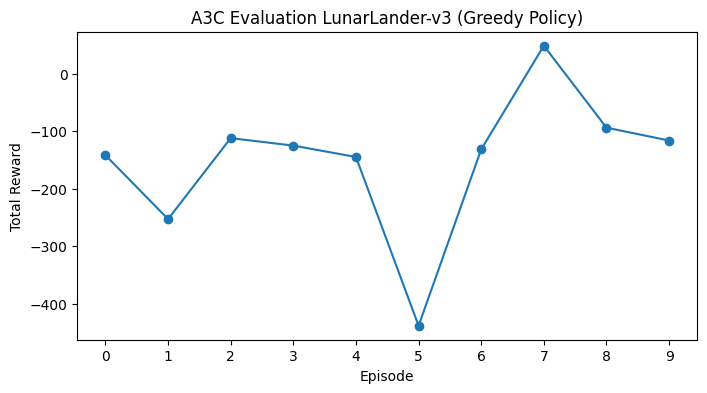

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(eval_rewards, marker='o')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('A3C Evaluation LunarLander-v3 (Greedy Policy)')
plt.xticks(range(10))
plt.show()

In [34]:
from save_rendered_video import run_and_record_one_episode

def greedy_policy(obs):
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0)
    with torch.no_grad():
        action_probs, _ = model(obs_tensor)
    return torch.argmax(action_probs).item()

run_and_record_one_episode('LunarLander-v3', greedy_policy, out_dir='videos')

/opt/homebrew/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/aryaapareshdeshpande/Desktop/Reinforcement Learning/Assignment 3 - Checkpoint attached files Apr 9, 2026 547 PM/Actor-Critic-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Saved video in videos. Episode reward: -127.65700633152312, steps: 68


# Acrobot-v1


In [7]:
model_2 = SharedActorCritic(6,256,3)
model_2.share_memory()

optimizer_2 = optim.Adam(model_2.parameters(), lr = 3e-4)

In [8]:
all_rewards_2 = {0: [], 1: []}
def workers(thread_id, global_model_2, optimizer_2, num_episodes, lock, all_rewards_2):
    env = gym.make('Acrobot-v1')

    for episode in range(num_episodes):
        obs,_ = env.reset()

        local_model = copy.deepcopy(global_model_2)

        log_probs = []
        values = []
        rewards = []


        done = False
        while not done:
            obs_tensor = torch.FloatTensor(obs).unsqueeze(0)
            action_probs, value = local_model(obs_tensor)
            dist = torch.distributions.Categorical(action_probs)
            action = dist.sample()
            prob = dist.log_prob(action)
            log_probs.append(prob)

            values.append(value.squeeze())

            action = action.item()
            obs, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            if terminated or truncated:
                done = True
        
        returns = []
        R = 0
        gamma = 0.99

        for reward in reversed(rewards):
            R = reward + gamma * R
            returns.insert(0, R)

        returns_tensor = torch.tensor(returns, dtype=torch.float32)
        log_probs_tensor = torch.stack(log_probs)
        values_tensor = torch.stack(values)

        advantage = (returns_tensor - values_tensor).detach()
        entropy = dist.entropy().mean()
        actor_loss = -(log_probs_tensor * advantage).mean() - 0.05 * entropy
        critic_loss = F.mse_loss(values_tensor,returns_tensor)

        with lock:
            optimizer_2.zero_grad()

            total_loss = actor_loss + critic_loss
            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(global_model_2.parameters(), max_norm=0.5)

            optimizer_2.step()
            all_rewards_2[thread_id].append(sum(rewards))
            print(f"Thread {thread_id} | Episode {episode} | Reward: {sum(rewards)}")

                        

In [9]:
lock = threading.Lock()
threads = []
for i in range(2):
    t = threading.Thread(target=workers, args=(i, model_2, optimizer_2, 2000, lock, all_rewards_2))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

Thread 0 | Episode 0 | Reward: -500.0
Thread 1 | Episode 0 | Reward: -500.0
Thread 0 | Episode 1 | Reward: -500.0
Thread 1 | Episode 1 | Reward: -393.0
Thread 0 | Episode 2 | Reward: -500.0
Thread 1 | Episode 2 | Reward: -500.0
Thread 0 | Episode 3 | Reward: -500.0
Thread 1 | Episode 3 | Reward: -500.0
Thread 0 | Episode 4 | Reward: -500.0
Thread 1 | Episode 4 | Reward: -500.0
Thread 0 | Episode 5 | Reward: -308.0
Thread 1 | Episode 5 | Reward: -500.0
Thread 0 | Episode 6 | Reward: -500.0
Thread 1 | Episode 6 | Reward: -500.0
Thread 0 | Episode 7 | Reward: -368.0
Thread 1 | Episode 7 | Reward: -500.0
Thread 0 | Episode 8 | Reward: -500.0
Thread 1 | Episode 8 | Reward: -500.0
Thread 0 | Episode 9 | Reward: -500.0
Thread 1 | Episode 9 | Reward: -500.0
Thread 0 | Episode 10 | Reward: -383.0
Thread 1 | Episode 10 | Reward: -378.0
Thread 0 | Episode 11 | Reward: -500.0
Thread 1 | Episode 11 | Reward: -440.0
Thread 0 | Episode 12 | Reward: -371.0
Thread 1 | Episode 12 | Reward: -500.0
Thread

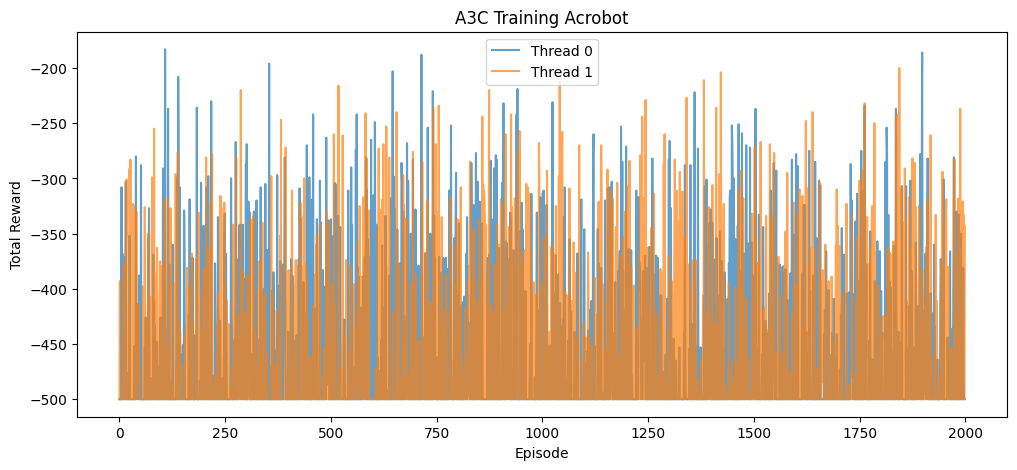

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(all_rewards_2[0], label='Thread 0', alpha=0.7)
plt.plot(all_rewards_2[1], label='Thread 1', alpha=0.7)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('A3C Training Acrobot')
plt.legend()
plt.show()

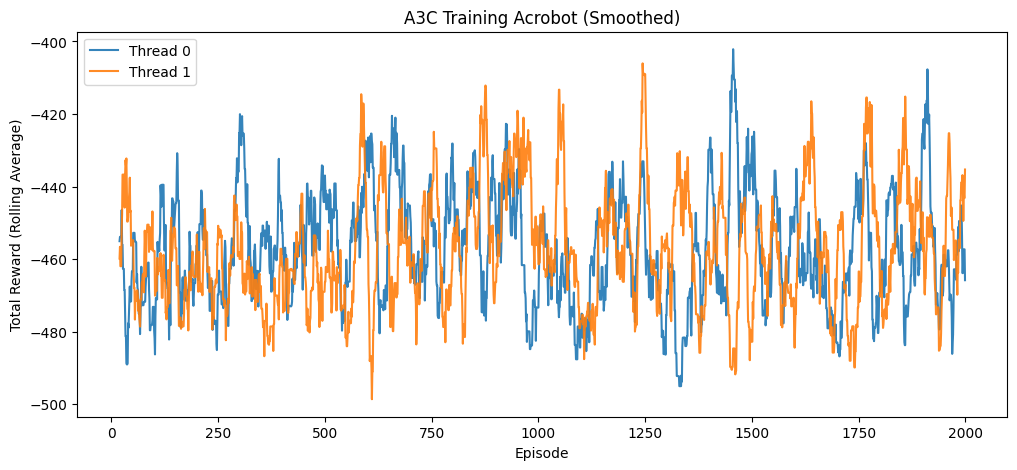

In [11]:
import pandas as pd

window = 20 

plt.figure(figsize=(12, 5))
plt.plot(pd.Series(all_rewards_2[0]).rolling(window).mean(), label='Thread 0', alpha=0.9)
plt.plot(pd.Series(all_rewards_2[1]).rolling(window).mean(), label='Thread 1', alpha=0.9)
plt.xlabel('Episode')
plt.ylabel('Total Reward (Rolling Average)')
plt.title('A3C Training Acrobot (Smoothed)')
plt.legend()
plt.show()

In [13]:
model_2.eval()
eval_rewards_2 = []
env = gym.make('Acrobot-v1')

for episode in range(10):
    obs, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0)

        action_probs, value = model_2(obs_tensor)
        action = torch.argmax(action_probs)
        action = action.item()
        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        if terminated or truncated:
            done = True
    
    eval_rewards_2.append(total_reward)
    print(f"Eval Episode {episode} | Reward: {total_reward}")

Eval Episode 0 | Reward: -146.0
Eval Episode 1 | Reward: -214.0
Eval Episode 2 | Reward: -428.0
Eval Episode 3 | Reward: -236.0
Eval Episode 4 | Reward: -212.0
Eval Episode 5 | Reward: -328.0
Eval Episode 6 | Reward: -229.0
Eval Episode 7 | Reward: -184.0
Eval Episode 8 | Reward: -350.0
Eval Episode 9 | Reward: -197.0


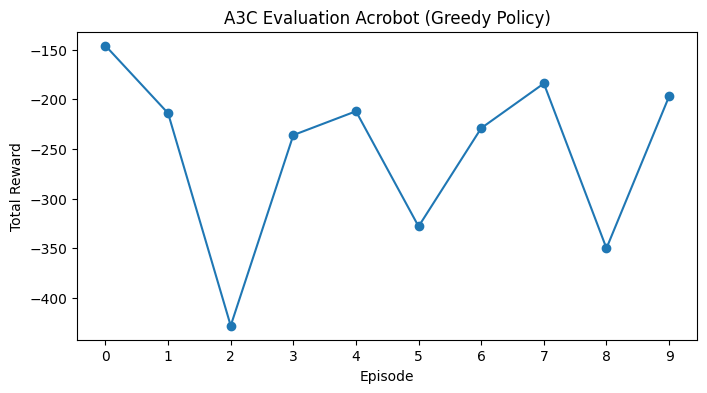

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(eval_rewards_2, marker='o')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('A3C Evaluation Acrobot (Greedy Policy)')
plt.xticks(range(10))
plt.show()